In [101]:
import numpy as np

import matplotlib.pyplot as plt

from scipy.integrate import quad
from scipy.constants import G, c, h, k, sigma
# G = gravitational constant, c = speed of light, h = Plank constant, k = Boltzmann constant, sigma = Stefan-Boltzmann constant

M_sun = 1.98847e30   # kg

import matplotlib.ticker as ticker
from scipy.interpolate import interp1d
plt.rcParams["font.family"] = "Times New Roman" #font

In [102]:
def disk_temp(R, M, Mdot, R_in):
    term = (3 * G * M * Mdot) / (8 * np.pi * R**3 * sigma)
    # R = radius of temp, M = NS mass, Mdot = mass accretion rate, R_in = inner edge
    boundary = 1 - np.sqrt(R_in / R)

    return (term * boundary)**0.25

In [103]:
# test 
M = 1.4 * M_sun  # mass of neutron star in kg

R_in = 12e3       # 12 km in meters
R_out = 1000e3    # 1000 km in meters

Mdot = 1e14       # kg/s

R = 20e3

T = disk_temp(R, M, Mdot, R_in)

print(T)
print(f"T = {T:.3e} K") # hehe

5761667.617098408
T = 5.762e+06 K


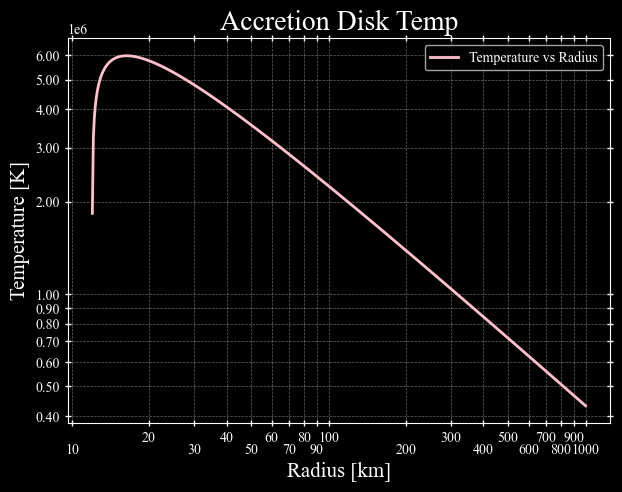

In [104]:
# plotting the temp based on R

#random radii
R_values = np.logspace(
    np.log10(R_in * 1.001),
    np.log10(R_out),
    500
)

T_values = disk_temp(R_values, M, Mdot, R_in)

#plotting time

plt.figure(figsize=(7, 5))
plt.loglog(R_values / 1000, T_values, label = "Temperature vs Radius", linewidth = 2, color = "pink") #legend


plt.xlabel("Radius [km]", fontsize = 15)
plt.ylabel("Temperature [K]", fontsize = 15)
plt.title("Accretion Disk Temp", fontsize = 20)
plt.legend()
plt.minorticks_on()

#tick stuff
plt.grid(True, which = "both", ls = "--", lw = 0.5, alpha = 0.4)
plt.tick_params(axis = "both", which = "both", top = True, right = True, direction = "inout" , length = 3, width = 1, size = 4)

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.LogLocator(base = 10, subs = np.arange(1.0, 10.0) * 0.1, numticks = 3))
ax.yaxis.set_major_locator(ticker.LogLocator(base = 10, subs = np.arange(1.0, 10.0) * 0.1, numticks = 3))
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

plt.ticklabel_format(axis = "both", style = "sci")
#end of tick stuff

plt.gcf().canvas.draw()
for i, j in enumerate(ax.xaxis.get_ticklabels()):
    if i % 2 != 0:
        j.set_y(j.get_position()[1] - 0.03)

# makes the ticks alternate

plt.show()



In [105]:
# adding in frequency

def plank_nu(nu, T):
    exponent = h * nu / (k * T)

    return (2 * h * nu**3 / c**2) / np.expm1(exponent)

# nu = frequency in Hertz, T = temp in K

In [106]:
def disk_integrand(R, nu, M, Mdot, R_in):
    T = disk_temp(R, M, Mdot, R_in)

    return 2 * np.pi * R * plank_nu(nu, T)

# ok so that's the stuff going into the integral done

# actual flux fn:

def disk_flux_nu(nu, M, Mdot, R_in, R_out, inclination, D):
    integral, error = quad(
        disk_integrand,
        R_in,
        R_out,
        args=(nu, M, Mdot, R_in)
    )

    F_nu = (np.cos(inclination) / D**2) * integral
    return F_nu

# make sure inclination is in radians when running
#use:
    # inclination = np.radians(angle)
    # np.cos(inclination)


In [107]:
# conversions

pc = 3.085677581e16   # meters
kpc = 1000 * pc

In [108]:
#testing the flux fn

M = 1.4 * M_sun
Mdot = 1e14

R_in = 12e3
R_out = 1000e3

inclination = np.radians(45)

pc = 3.085677581e16
kpc = 1000 * pc
D = 5 * kpc
nu = 1e17   # Hz

F_nu = disk_flux_nu( 
    nu,
    M,
    Mdot,
    R_in,
    R_out,
    inclination,
    D)

print(F_nu)

# yay it works!

8.773419085173337e-30


/var/folders/kn/xzl7br5d4pz_j1v8fs130kch0000gn/T/ipykernel_82613/499825638.py:6: RuntimeWarning: overflow encountered in expm1
  return (2 * h * nu**3 / c**2) / np.expm1(exponent)


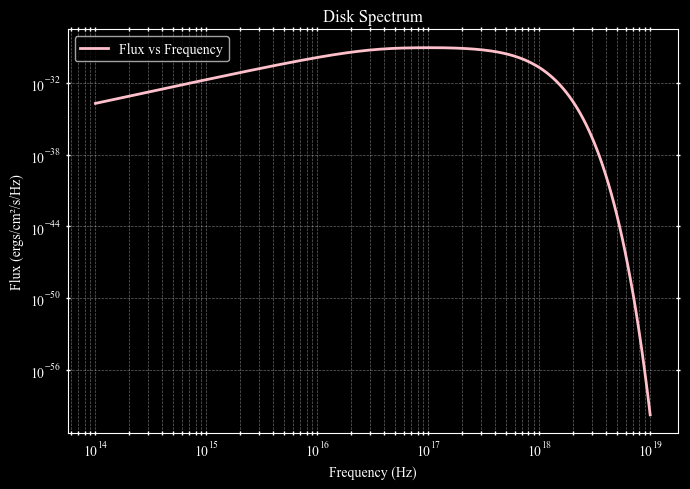

In [109]:
# time to try a spectrum!

#generating frequencies
frequencies = np.logspace(14, 19, 200)  # in Hz obvi

fluxes = []

for nu in frequencies:
    F = disk_flux_nu(
        nu,
        M,
        Mdot,
        R_in,
        R_out,
        inclination,
        D
    )
    fluxes.append(F)

fluxes = np.array(fluxes)

#plotting time

plt.figure(figsize=(7, 5))
plt.loglog(frequencies, fluxes, label = "Flux vs Frequency", linewidth = 2, color = "pink") #legend
plt.xlabel("Frequency (Hz)")
plt.ylabel("Flux (ergs/cm²/s/Hz)")
plt.title("Disk Spectrum")
plt.legend()

plt.minorticks_on()


# grid
plt.grid(
    True,
    which="both",
    ls="--",
    lw=0.5,
    alpha=0.4
)

# tick styling
plt.tick_params(
    axis="both",
    which="both",
    top=True,
    right=True,
    direction="inout",
    length=3,
    width=1
)

ax = plt.gca()


# log tick locations
ax.xaxis.set_major_locator(
    ticker.LogLocator(
        base=10,
        numticks=6
    )
)

ax.yaxis.set_major_locator(
    ticker.LogLocator(
        base=10,
        numticks=6
    )
)

# scientific notation labels
ax.xaxis.set_major_formatter(
    ticker.LogFormatterSciNotation(base=10)
)

ax.yaxis.set_major_formatter(
    ticker.LogFormatterSciNotation(base=10)
)

# makes graph fit nicely
plt.tight_layout()

plt.show()

/var/folders/kn/xzl7br5d4pz_j1v8fs130kch0000gn/T/ipykernel_82613/499825638.py:6: RuntimeWarning: overflow encountered in expm1
  return (2 * h * nu**3 / c**2) / np.expm1(exponent)
/var/folders/kn/xzl7br5d4pz_j1v8fs130kch0000gn/T/ipykernel_82613/2174342785.py:11: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  integral, error = quad(


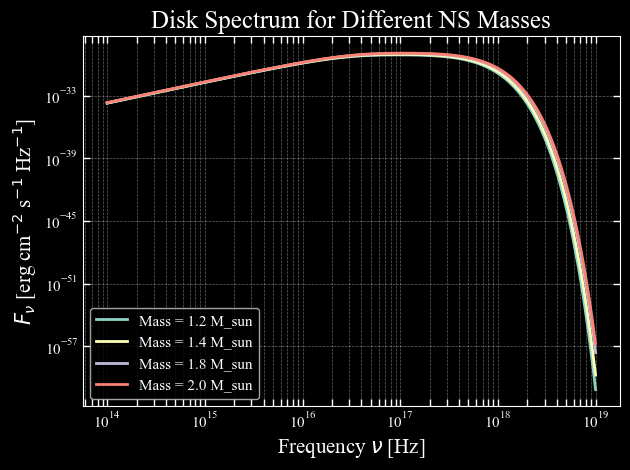

In [110]:
#varying NS mass

#ex
masses = [1.2, 1.4, 1.8, 2.0]

for mass in masses:
    M = mass * M_sun
    fluxes = []
    for nu in frequencies:
        F = disk_flux_nu(
            nu,
            M,
            Mdot,
            R_in,
            R_out,
            inclination,
            D
        )
        fluxes.append(F)
    fluxes = np.array(fluxes)

  # convert W/m^2/Hz -> erg/s/cm^2/Hz
    fluxes_cgs = fluxes * 1e3

    plt.loglog(
        frequencies, 
        fluxes, 
        label = f"Mass = {mass} M_sun", 
        linewidth = 2
        )

# labels
plt.xlabel(r"Frequency $\nu$ [Hz]", fontsize=15)

plt.ylabel(
    r"$F_\nu$ [erg cm$^{-2}$ s$^{-1}$ Hz$^{-1}$]",
    fontsize=15
)

plt.title(
    "Disk Spectrum for Different NS Masses",
    fontsize=18
)


# legend
plt.legend(
    fontsize=11,
    frameon=True
)


# minor ticks
plt.minorticks_on()


# grid stuff
plt.grid(
    True,
    which="both",
    ls="--",
    lw=0.5,
    alpha=0.4
)

# tick styling
plt.tick_params(
    axis="both",
    which="both",
    top=True,
    right=True,
    direction="in",
    length=5,
    width=1
)


# get current axes
ax = plt.gca()


# x-axis log ticks
ax.xaxis.set_major_locator(
    ticker.LogLocator(
        base=10,
        numticks=6
    )
)

# y-axis log ticks
ax.yaxis.set_major_locator(
    ticker.LogLocator(
        base=10,
        numticks=6
    )
)

# formatting as 10^x
ax.xaxis.set_major_formatter(
    ticker.LogFormatterSciNotation(base=10)
)

ax.yaxis.set_major_formatter(
    ticker.LogFormatterSciNotation(base=10)
)


# increasing tick label size
ax.tick_params(
    axis="both",
    labelsize=11
)


# making sure labels don't get cut off
plt.tight_layout()

plt.show()

/var/folders/kn/xzl7br5d4pz_j1v8fs130kch0000gn/T/ipykernel_82613/499825638.py:6: RuntimeWarning: overflow encountered in expm1
  return (2 * h * nu**3 / c**2) / np.expm1(exponent)
/var/folders/kn/xzl7br5d4pz_j1v8fs130kch0000gn/T/ipykernel_82613/2174342785.py:11: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  integral, error = quad(


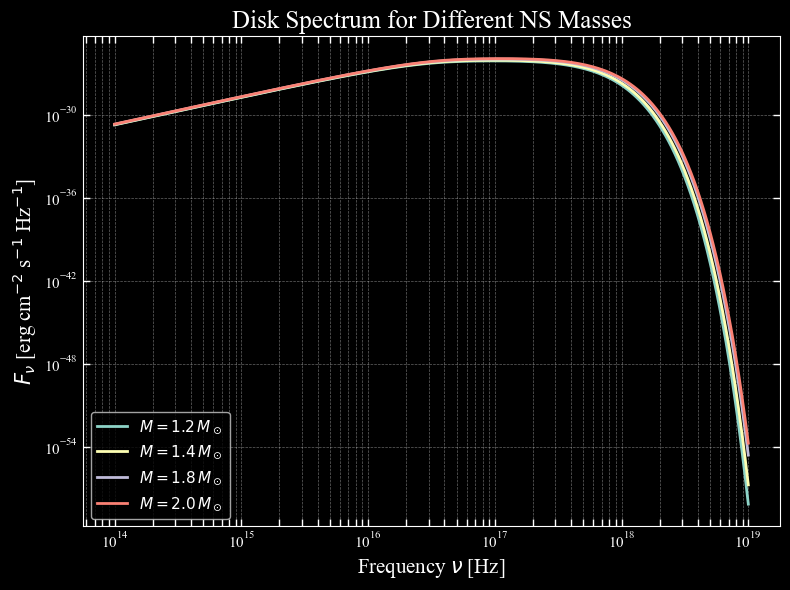

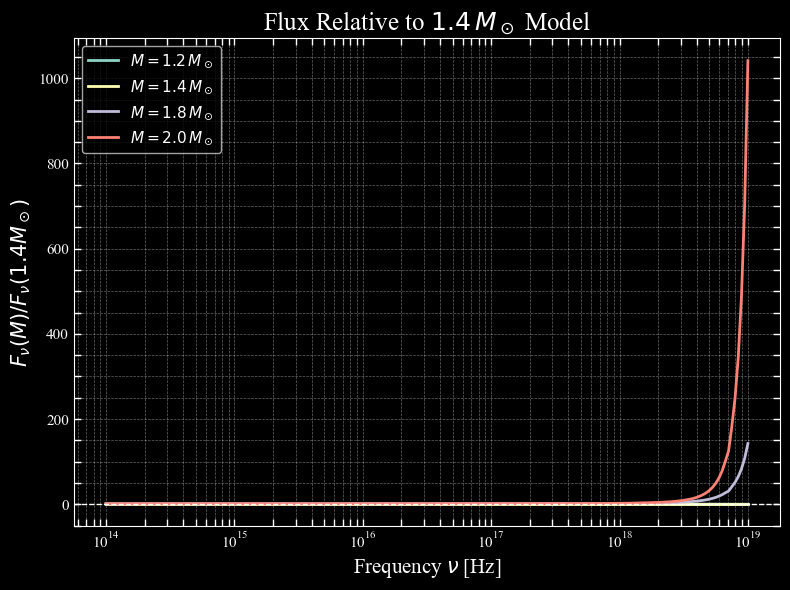

In [111]:
# this is the same as above but I'm attempting to make it more readable? idk it looks supa tight right now so I am consulting the internet for help but not sure if this is a good official practice

# varying NS mass (pt. 2)

masses = [1.2, 1.4, 1.8, 2.0]

# dictionary to store each spectrum
spectra = {}

plt.figure(figsize=(8, 6))

for mass in masses:

    M = mass * M_sun

    fluxes = []

    for nu in frequencies:

        F = disk_flux_nu(
            nu,
            M,
            Mdot,
            R_in,
            R_out,
            inclination,
            D
        )

        fluxes.append(F)

    fluxes = np.array(fluxes)

    # convert from W/m^2/Hz to erg/s/cm^2/Hz
    fluxes_cgs = fluxes * 1e3

    # save spectrum so we can use it later
    spectra[mass] = fluxes_cgs

    # plot spectrum
    plt.loglog(
        frequencies,
        fluxes_cgs,
        label=fr"$M = {mass}\,M_\odot$",
        linewidth=2
    )


# labels
plt.xlabel(r"Frequency $\nu$ [Hz]", fontsize=15)

plt.ylabel(
    r"$F_\nu$ [erg cm$^{-2}$ s$^{-1}$ Hz$^{-1}$]",
    fontsize=15
)

plt.title(
    "Disk Spectrum for Different NS Masses",
    fontsize=18
)

plt.legend(fontsize=11)

plt.minorticks_on()

plt.grid(
    True,
    which="both",
    ls="--",
    lw=0.5,
    alpha=0.4
)

plt.tick_params(
    axis="both",
    which="both",
    top=True,
    right=True,
    direction="in",
    length=5,
    width=1
)

ax = plt.gca()

ax.xaxis.set_major_locator(
    ticker.LogLocator(base=10, numticks=6)
)

ax.yaxis.set_major_locator(
    ticker.LogLocator(base=10, numticks=6)
)

ax.xaxis.set_major_formatter(
    ticker.LogFormatterSciNotation(base=10)
)

ax.yaxis.set_major_formatter(
    ticker.LogFormatterSciNotation(base=10)
)

ax.tick_params(
    axis="both",
    labelsize=11
)

plt.tight_layout()

plt.show()


# flux ratio relative to 1.4 solar masses bc it is allegedly a good reference pt...

reference_mass = 1.4

reference_flux = spectra[reference_mass]

plt.figure(figsize=(8, 6))

for mass in masses:

    flux_ratio = spectra[mass] / reference_flux

    plt.semilogx(
        frequencies,
        flux_ratio,
        label=fr"$M = {mass}\,M_\odot$",
        linewidth=2
    )


# reference line
plt.axhline(
    y=1,
    linestyle="--",
    linewidth=1
)


plt.xlabel(
    r"Frequency $\nu$ [Hz]",
    fontsize=15
)

plt.ylabel(
    r"$F_\nu(M) / F_\nu(1.4M_\odot)$",
    fontsize=15
)

plt.title(
    r"Flux Relative to $1.4\,M_\odot$ Model",
    fontsize=18
)

plt.legend(fontsize=11)

plt.minorticks_on()

plt.grid(
    True,
    which="both",
    ls="--",
    lw=0.5,
    alpha=0.4
)

plt.tick_params(
    axis="both",
    which="both",
    top=True,
    right=True,
    direction="in",
    length=5,
    width=1
)

ax = plt.gca()

ax.xaxis.set_major_locator(
    ticker.LogLocator(base=10, numticks=6)
)

ax.xaxis.set_major_formatter(
    ticker.LogFormatterSciNotation(base=10)
)

ax.tick_params(
    axis="both",
    labelsize=11
)

plt.tight_layout()

plt.show()

# 1.4 case is at one and you can see everything else a lot better!

/var/folders/kn/xzl7br5d4pz_j1v8fs130kch0000gn/T/ipykernel_82613/499825638.py:6: RuntimeWarning: overflow encountered in expm1
  return (2 * h * nu**3 / c**2) / np.expm1(exponent)
/var/folders/kn/xzl7br5d4pz_j1v8fs130kch0000gn/T/ipykernel_82613/2174342785.py:11: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  integral, error = quad(


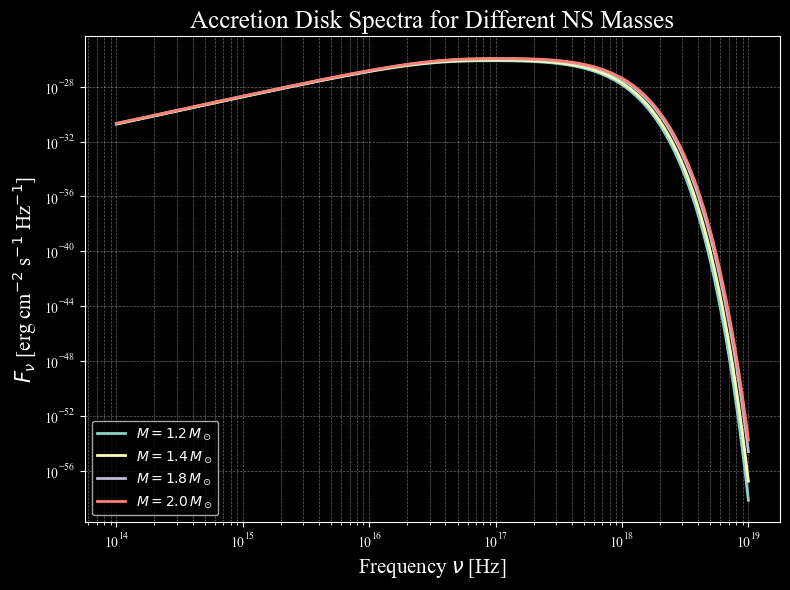

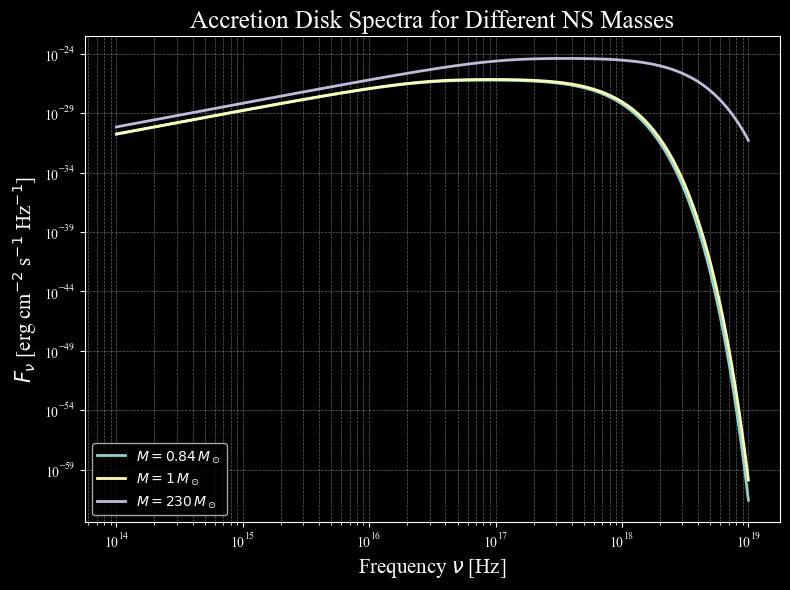

In [112]:
# making a general case

def compare_ns_masses(
        masses,
        frequencies,
        Mdot,
        R_in,
        R_out,
        inclination,
        D
):

    plt.figure(figsize=(8, 6))

    for mass in masses:
        M = mass * M_sun
        fluxes = []
        for nu in frequencies:
            F = disk_flux_nu(
                nu,
                M,
                Mdot,
                R_in,
                R_out,
                inclination,
                D
            )
            fluxes.append(F)
        fluxes = np.array(fluxes)

        # convert from W/m^2/Hz to erg/s/cm^2/Hz
        fluxes_cgs = fluxes * 1e3

        plt.loglog(
            frequencies,
            fluxes_cgs,
            label=fr"$M = {mass}\,M_\odot$",
            linewidth=2
        )

    plt.xlabel(r"Frequency $\nu$ [Hz]", fontsize=15)
    plt.ylabel(
        r"$F_\nu$ [erg cm$^{-2}$ s$^{-1}$ Hz$^{-1}$]",
        fontsize=15
    )

    plt.title(
        "Accretion Disk Spectra for Different NS Masses",
        fontsize=18
    )

    plt.grid(
        True,
        which="both",
        ls="--",
        lw=0.5,
        alpha=0.4
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

#ex

masses = [1.2, 1.4, 1.8, 2.0]

frequencies = np.logspace(14, 19, 200)

compare_ns_masses(
    masses,
    frequencies,
    Mdot,
    R_in,
    R_out,
    inclination,
    D
)

#ex 2

masses = [0.84, 1, 230]
# smallest star, sun, largest star higher limit

frequencies = np.logspace(14, 19, 200)

compare_ns_masses(
    masses,
    frequencies,
    Mdot,
    R_in,
    R_out,
    inclination,
    D
)

